# Прогнозирование продаж в магазинах офлайн-ритейлера в США (соврменные методы)


В этом ноутбуке решается задача прогнозирования ежедневных продаж для выбранного магазина на основе **градиентного бустинга**.

В отличие от классических моделей временных рядов (ARIMA/ETS/SARIMA), бустинг решает задачу как **регрессию по признакам**:

- **лаги** и **скользящие статистики** по продажам,
- календарные признаки (день недели, месяц, праздники/события),
- внешние признаки: **средняя цена** по магазину (по неделе) и **кэшбек/промо** из календаря.

Мы обучим модель на train-части и сделаем **рекурсивный прогноз** на горизонте *H* дней, используя свои предсказания для формирования лагов внутри горизонта.


In [2]:
import warnings

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from forecaster import RetailSalesGBForecaster

warnings.filterwarnings("ignore")

plt.style.use("seaborn-v0_8")
sns.set_theme(font_scale=1.1)

In [3]:
sales = pd.read_csv("../data/shop_sales.csv")
calendar = pd.read_csv("../data/shop_sales_dates.csv")
prices = pd.read_csv("../data/shop_sales_prices.csv")

sales.head()

,item_id,store_id,date_id,cnt
0,STORE_2_085,STORE_2,1,3
1,STORE_2_085,STORE_2,2,8
2,STORE_2_085,STORE_2,3,0
3,STORE_2_085,STORE_2,4,3
4,STORE_2_085,STORE_2,5,0


In [4]:
stores = list(sales["store_id"].unique())

selected_store = "STORE_2"

sales_store = (
    sales[sales["store_id"] == selected_store]
    .groupby("date_id", as_index=False)["cnt"]
    .sum()
    .sort_values("date_id")
)

sales_store["store_id"] = selected_store
sales_store

,date_id,cnt,store_id
0,1,275,STORE_2
1,2,320,STORE_2
2,3,211,STORE_2
3,4,370,STORE_2
4,5,344,STORE_2
...,...,...,...
1814,1815,380,STORE_2
1815,1816,277,STORE_2
1816,1817,286,STORE_2
1817,1818,269,STORE_2


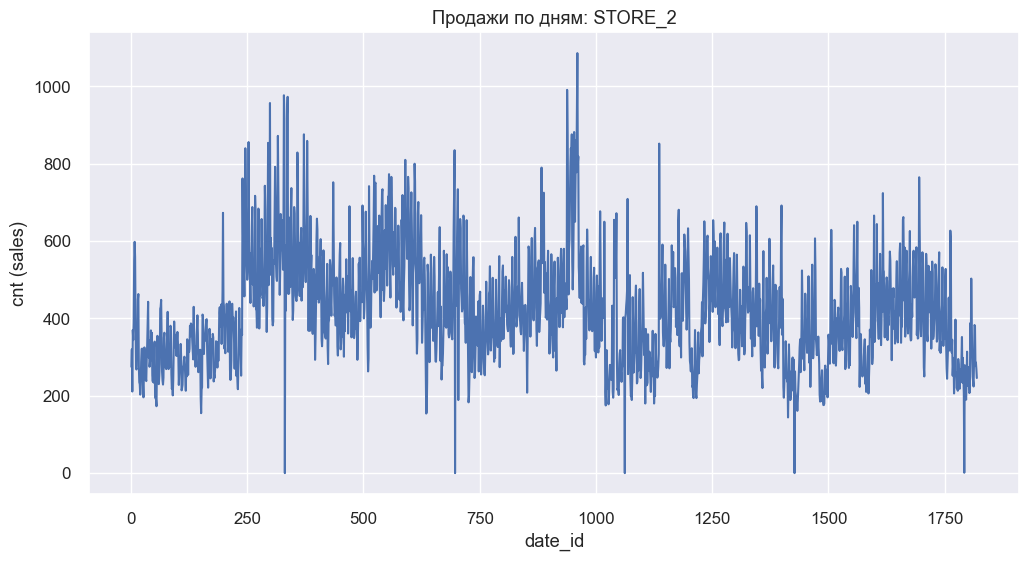

In [5]:
plt.figure(figsize=(12, 6))
plt.plot(sales_store["date_id"].values, sales_store["cnt"].values)
plt.title(f"Продажи по дням: {selected_store}")
plt.xlabel("date_id")
plt.ylabel("cnt (sales)")
plt.show()

# Прогнозирование

Спрогнозируем продажи с помощью класса `RetailSalesGBForecaster`, который строит признаки (лаги/скользящие + календарь/цена/промо) и обучает модель градиентного бустинга.

In [6]:
forecaster = RetailSalesGBForecaster(
    sales_df=sales,
    calendar_df=calendar,
    prices_df=prices,
    date_col="date_id",
    target_col="cnt",
    store_col="store_id",
    store_id=selected_store,
    test_size=90,          # последние 90 дней оставляем под тест
    lags=(1, 7, 14, 28),
    rolling_windows=(7, 28),
)

print("Train length:", len(forecaster.train_))
print("Test length:", len(forecaster.test_))
forecaster.series_original_.head()


Train length: 1729
Test length: 90


date
2011-01-29    275.0
2011-01-30    320.0
2011-01-31    211.0
2011-02-01    370.0
2011-02-02    344.0
Name: cnt, dtype: float64

### Описание класса `RetailSalesGBForecaster`

Для прогнозирования были использованы CatBoost / LightGBM / XGBoost.

Концептуально происходит следющее:
- превращаем задачу временного ряда в задачу регрессии: y(t) = f(лаги, скользящие, календарь, цена, промо)
- обучаем модель на историических данных и делаем рекурсивный прогноз на горизонте H,
  используя собственные предсказания для формирования лагов внутри горизонта.

Что внутри себя аггрегирует класс, по шагам:
- Приводит продажи к одному ежедневному ряду по выбранному магазину (агрегация по `date_id`).
- Присоединяет календарь (`shop_sales_dates.csv`) по `date_id`, добавляет базовые календарные признаки.
- Строит внешние признаки:
  - средняя цена магазина по неделе (`avg_sell_price`) из `shop_sales_prices.csv`,
  - кэшбек/промо из календаря (при наличии столбца `CASHBACK_STORE_X`).
- Превращает ряд в обучающую таблицу с лагами и скользящими статистиками.
- Обучает градиентный бустинг.
- Делает рекурсивный прогноз на горизонте H дней: признаки лагов внутри горизонта строятся на основе собственных предсказаний.

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001766 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3037
[LightGBM] [Info] Number of data points in the train set: 1701, number of used features: 26
[LightGBM] [Info] Start training from score 426.634333
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain

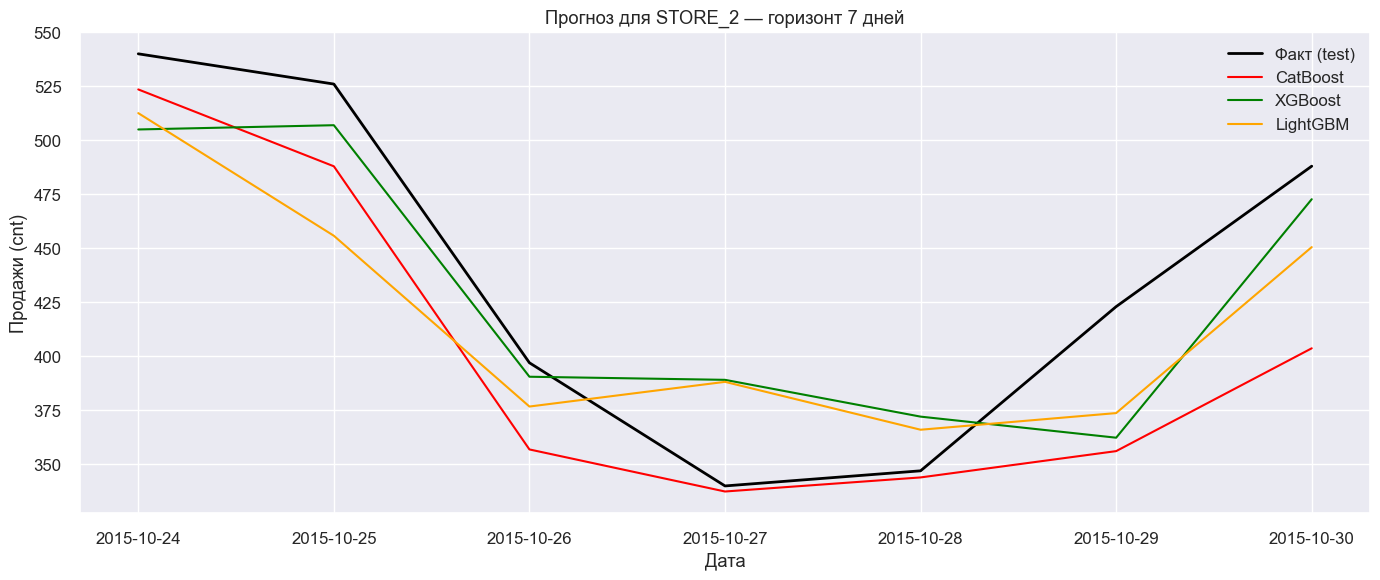

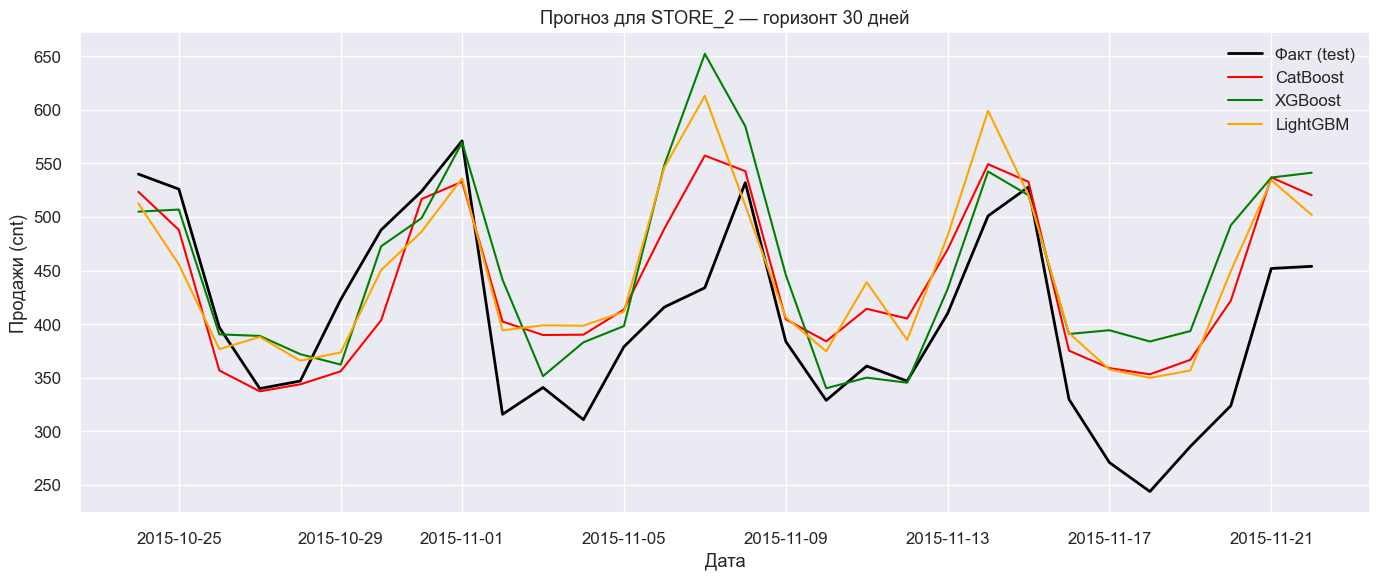

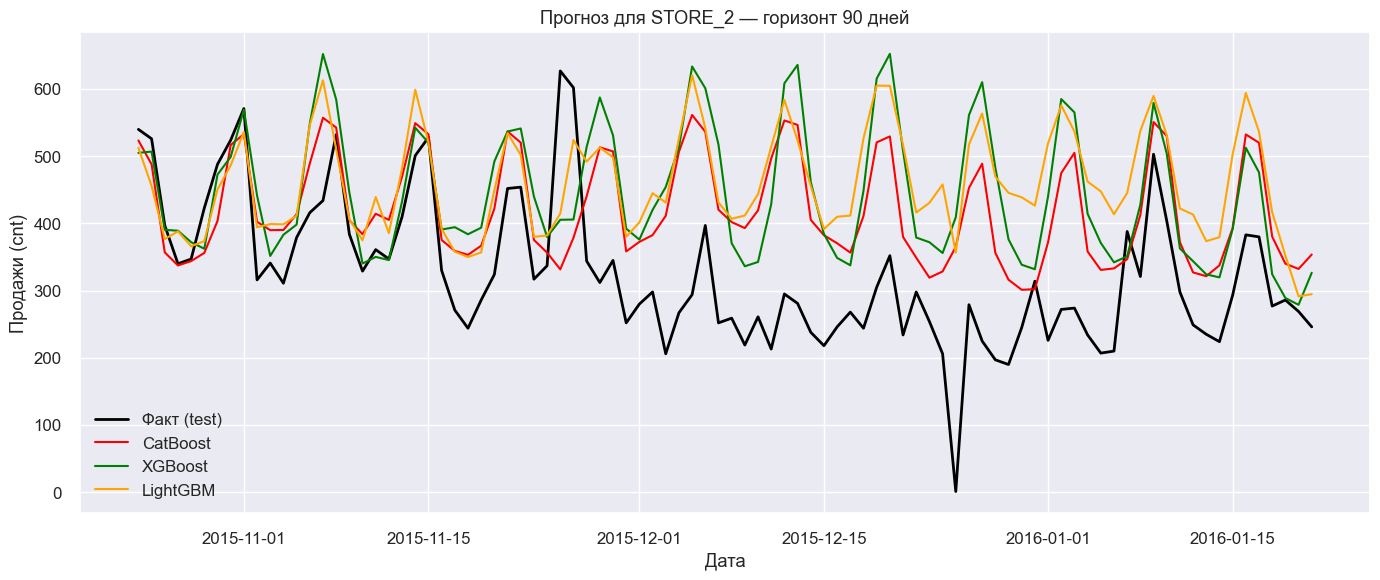

In [7]:
h = len(forecaster.test_)
fc_cat_full = forecaster.forecast(model_name="catboost", horizon=h)
fc_lightgbm_boost_full = forecaster.forecast(model_name="lightgbm", horizon=h)
fc_xgboost_boost_full = forecaster.forecast(model_name="xgboost", horizon=h)

horizons = [7, 30, 90]
for h in horizons:
    plt.figure(figsize=(14, 6))

    # Фактические данные для горизонта h
    plt.plot(
        forecaster.test_.index[:h],
        forecaster.test_.values[:h],
        label="Факт (test)",
        linewidth=2,
        color="black"
    )

    # Прогнозы (обрезанные до горизонта h)
    plt.plot(
        fc_cat_full.index[:h],
        fc_cat_full.values[:h],
        label="CatBoost",
        color="red"
    )
    plt.plot(
        fc_lightgbm_boost_full.index[:h],
        fc_lightgbm_boost_full.values[:h],
        label="XGBoost",
        color="green"
    )
    plt.plot(
        fc_xgboost_boost_full.index[:h],
        fc_xgboost_boost_full.values[:h],
        label="LightGBM",
        color="orange"
    )

    plt.title(
        f"Прогноз для {selected_store} — горизонт {h} дней"
    )
    plt.xlabel("Дата")
    plt.ylabel("Продажи (cnt)")
    plt.legend()
    plt.tight_layout()
    plt.show()

# Оценка метрик качества

Посчитаем MAE / RMSE / MAPE для горизонтов 7, 30 и 90 дней. Для бустинга это означает рекурсивный прогноз на первые *h* дней теста.

In [8]:
horizons = [7, 30, 90]
metrics_summary = forecaster.evaluate(horizons=horizons, models=("catboost", "lightgbm", "xgboost"))
metrics_summary

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001389 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3037
[LightGBM] [Info] Number of data points in the train set: 1701, number of used features: 26
[LightGBM] [Info] Start training from score 426.634333
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain

,model,horizon,MAE,RMSE,MAPE
0,catboost,7,35.923216,2131.990538,7.873552
1,catboost,30,54.205341,3985.593015,14.974803
2,catboost,90,113.802869,18707.221660,443.300102
3,lightgbm,7,30.094981,1226.565233,7.268406
4,lightgbm,30,59.937427,6608.828405,16.877185
5,lightgbm,90,132.823998,27869.123951,499.443455
6,xgboost,7,38.834189,1801.007843,8.929626
7,xgboost,30,62.527939,5351.179744,16.954977
8,xgboost,90,147.269417,29928.690613,447.082558


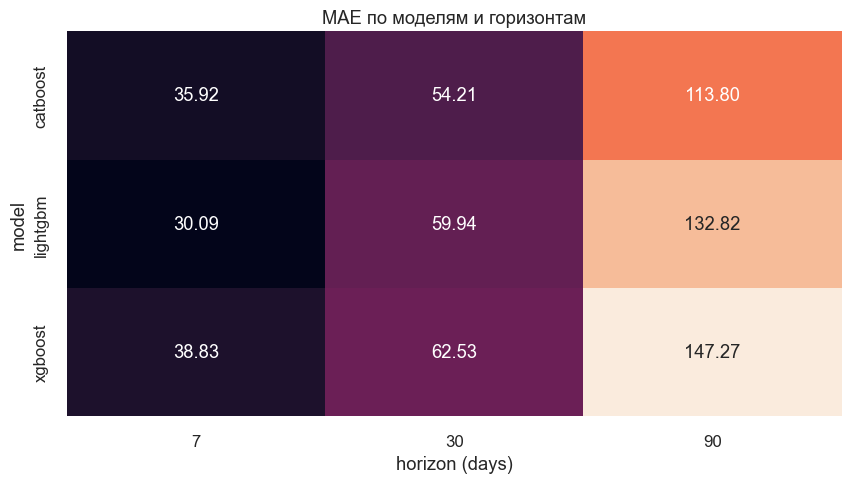

In [9]:
plt.figure(figsize=(10, 5))
pivot = metrics_summary.pivot(index="model", columns="horizon", values="MAE")
sns.heatmap(pivot, annot=True, fmt=".2f", cbar=False)
plt.title("MAE по моделям и горизонтам")
plt.xlabel("horizon (days)")
plt.ylabel("model")
plt.show()

## Используем метрики MAE, RMSE и MAPE.

- MAE показывает среднюю абсолютную ошибку в единицах продаж и легко интерпретируется бизнесом.
- RMSE сильнее штрафует большие промахи, что важно для выявления редких, но критичных ошибок.
- MAPE отражает относительную ошибку в процентах, позволяя сравнивать качество на разных горизонтах и уровнях спроса.

Вместе они дают сбалансированную картину: MAE — «типичная» ошибка, RMSE — чувствительность к выбросам, MAPE — относительное качество прогноза.

## Итоговое качество на тесте.

Лучшие результаты показал LightGBM на коротком горизонте (7 дней): MAE ≈ 30.1, RMSE ≈ 35.0, MAPE ≈ 7.27%.
На средних и длинных горизонтах (30 и 90 дней) ошибки ожидаемо растут у всех моделей;
CatBoost и LightGBM сопоставимы, при этом относительная ошибка (MAPE) резко увеличивается на 90 дней из-за низких фактических значений и накопления неопределённости.

## Важность признаков

Посмотрим, какие признаки оказались наиболее значимыми для модели (по важности признаков).

In [10]:
fi = forecaster.feature_importance(model_name="catboost", top_n=20)
fi

,feature,importance
0,lag_1,16.882530
1,roll_mean_7,7.766640
2,weekday,6.343882
3,dayofweek,5.809736
4,roll_std_7,5.295698
5,lag_14,5.288569
6,lag_7,5.018008
7,day,4.958800
8,lag_28,4.658742
9,roll_mean_28,4.224712


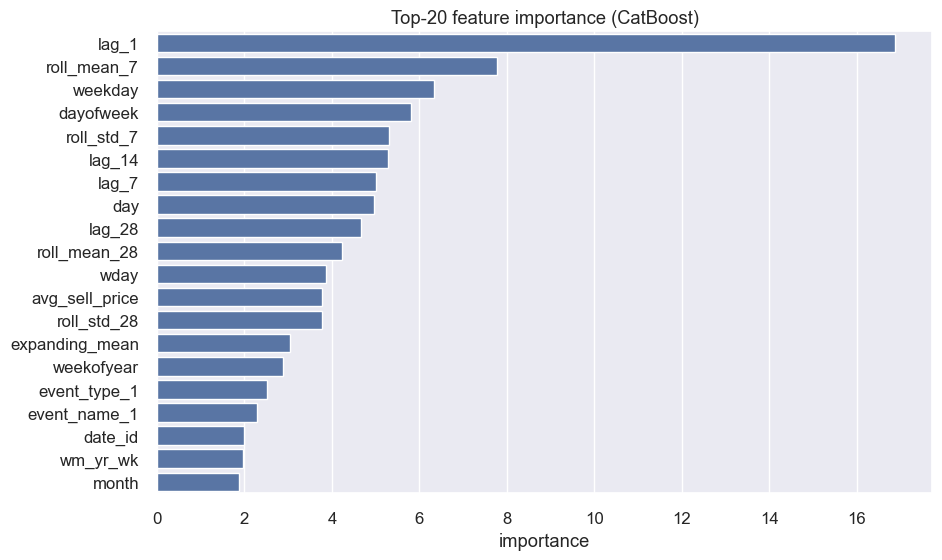

In [11]:
plt.figure(figsize=(10, 6))
sns.barplot(data=fi, y="feature", x="importance")
plt.title("Top-20 feature importance (CatBoost)")
plt.xlabel("importance")
plt.ylabel("")
plt.show()

## Интерпретация результатов

- Модель в первую очередь опирается на исторические значения продаж: самый важный признак — lag_1, а также недельные и месячные лаги и скользящие статистики, что указывает на сильную автокорреляцию и выраженную недельную сезонность.
- Календарные признаки (день недели, день, неделя и месяц) вносят существенный вклад, отражая регулярные сезонные и внутринедельные паттерны спроса.
- Ценовой фактор (avg_sell_price) и события (event_name_1, event_type_1) оказывают дополнительное, но менее значимое влияние, корректируя базовый прогноз.

В целом модель сочетает временную динамику, сезонность и внешние факторы, что обеспечивает интерпретируемый и устойчивый прогноз.


## Ответы на вопросы

#### 1. Какие методы предобработки данных вы использовали? Почему?

1) **Фильтрация по магазину** (`store_id`) — чтобы прогнозировать один агрегированный ряд.  
2) **Агрегация по дням** (`date_id`) — приводим продажи к одному ряду *cnt(date)*.  
3) **Выравнивание по дневной частоте** — добавляем пропущенные дни и заполняем продажи нулями (в ритейле это типично).  
4) **Присоединение календаря/событий** — позволяет учесть праздники, выходные и другие эффекты.  
5) **Присоединение цены** — усредняем цену магазина по неделе и мержим по `wm_yr_wk`.

#### 2. Какие признаки использованы в градиентном бустинге?

- лаги продаж: 1, 7, 14, 28  
- скользящее среднее/стандартное отклонение по окнам 7 и 28  
- календарные признаки: день недели, день месяца, неделя года, месяц, год  
- категории событий: `event_name_*`, `event_type_*`, `weekday`  
- внешние: `avg_sell_price`, (если доступно) кэшбек/промо `CASHBACK_STORE_*`

#### 3. Почему рекурсивный прогноз?

Это простой и широко применяемый способ получить прогноз на несколько дней вперёд для моделей регрессии:  
мы предсказываем следующий день, добавляем предсказание в историю и повторяем *H* раз.

In [15]:
model = forecaster.get_model(model_name="catboost")
# model.get_leaf_weights()
# model = forecaster.get_model(model_name="catboost")
model.save_model("catboost_model.cbm")


In [16]:
model = forecaster.get_model(model_name="lightgbm")
model.booster_.save_model("lightgbm_model.txt")